OUTLIERS DETECTION AND CORRECTION

In [154]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn import ensemble

import scripts_for_E5 as s

In [155]:
# Load the database after handling missing values
db = pd.read_csv('db_missing_values_handled.csv')

In [156]:
# Convert data types
bool_cols = ['Alimentare', 'Non Alimentare', 'Tabella Speciale Carburanti', 'Tabella Speciale Farmacie', 'Tabella Speciale Monopolio']
db[bool_cols] = db[bool_cols].astype("boolean")

db["Codice Via"] = db["Codice Via"].astype("Int64")
db["ZD"] = db["ZD"].astype("Int64")

In [157]:
# Extract Civico number

df = pd.DataFrame()

def extract_civico_number(civico_string):
    # Extracts the leading numerical part from a Civico string
    if not isinstance(civico_string, str):
        return np.nan

    match = re.match(r'^(\d+)', civico_string)

    if match:
        return int(match.group(1))
    else:
        # No leading number found
        return np.nan

df["Civico"] = db["Civico"].apply(extract_civico_number)

# Fill missing Civico values with 0 for outlier detection
df["Civico"] = df["Civico"].fillna(0)

df["Via"] = db["Via"]

In [158]:
# Detect outliers in Civico using Standard Deviation method
def STD(data, th):
    mean = data.mean()
    std = data.std()
    V1 = mean + th * std
    V2 = mean - th * std
    outliers = []
    for d in data:
        if (d > V1) | (d < V2):
            outliers.append(d)

    return outliers

# Detect outliers in 'Civico' column
STD(df['Civico'], 1)

[40947.0, 41009.0, 40920.0, 40945.0, 591.0]

In [159]:
df["Civico"].mean()

np.float64(37.46213125621478)

In [160]:
# Outlier Detection based on Street Sequence Analysis
def find_sequence_outliers(group):
    # Sort to analyze the sequence (10, 12, 14...)
    # We keep the original index so we can map it back later
    group_sorted = group.sort_values()
    
    # Calculate the jump from the previous number
    diffs = group_sorted.diff()
    
    # Calculate Street Statistics
    street_std = group_sorted.std()
    
    # If we can't calculate a jump (only 1 item) or STD is 0
    # We relies solely on the hard limit > 4000
    if pd.isna(street_std) or street_std == 0:
        return group_sorted > 4000
    
    # Define the parameters
    multiplier = 2
    safe_floor = 37 # Numbers below the mean previously computed are trusted
    hard_ceiling = 4000 # Numbers above this are always outliers
    
    # The combined logic
    # Condition 1: The jump is too big (relative to this street's variance)
    is_jump_outlier = (group_sorted > safe_floor) & (diffs > (multiplier * street_std))
    
    # Condition 2: The number is just too big
    is_hard_outlier = group_sorted > hard_ceiling
    
    # Combine with OR
    return is_jump_outlier | is_hard_outlier

# Detect outliers in 'Civico' column
df['is_outlier'] = df.groupby('Via')['Civico'].transform(find_sequence_outliers)

In [161]:
# Show outlier counts
print(df["is_outlier"].value_counts())

is_outlier
False    24106
True        30
Name: count, dtype: int64


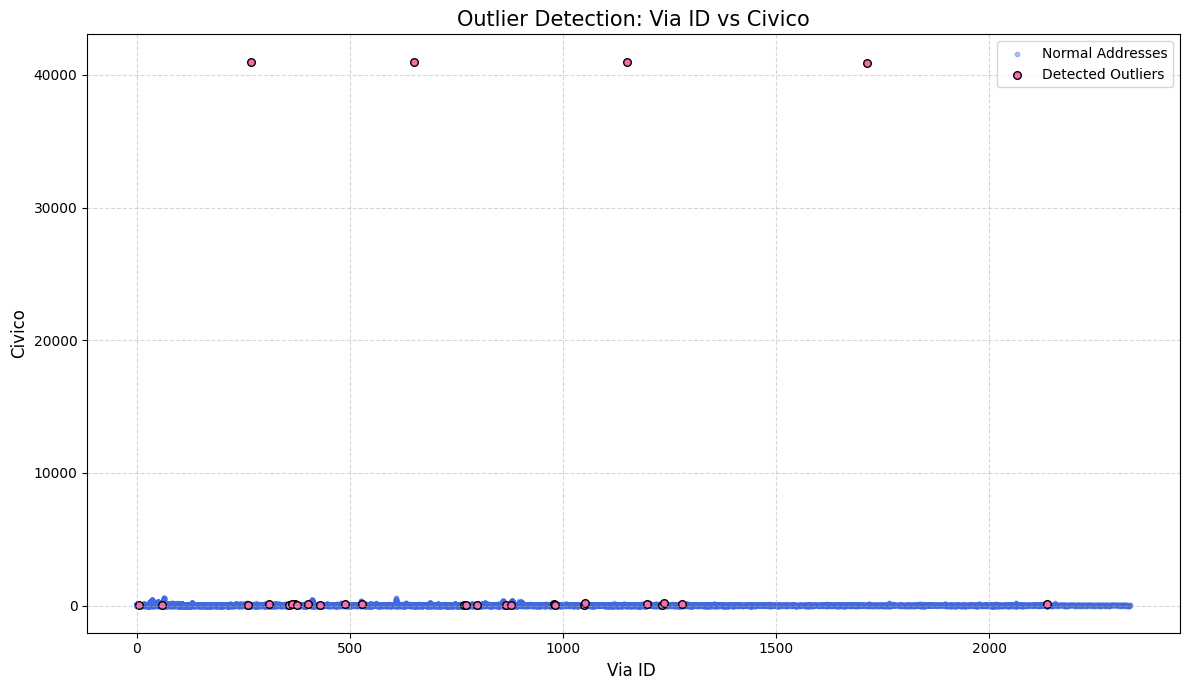

In [162]:
# Plot Civico with respect to the Via they belong to

# Encode the Via as ordinal numbers (0, 1, 2...)
# This creates a numeric 'Via_ID' so we can plot it on the X-axis
df['Via ID'] = pd.factorize(df['Via'])[0]

# Separate the data into normal and outliers with different colors
normal = df[df['is_outlier'] == False]
outliers = df[df['is_outlier'] == True]

plt.figure(figsize=(12, 7))

plt.scatter(normal['Via ID'], normal['Civico'], 
            c='royalblue', s=10, alpha=0.4, label='Normal Addresses')

plt.scatter(outliers['Via ID'], outliers['Civico'], 
            c='hotpink', s=30, alpha=1.0, label='Detected Outliers', edgecolor='black')

plt.title('Outlier Detection: Via ID vs Civico', fontsize=15)
plt.xlabel('Via ID ', fontsize=12)
plt.ylabel('Civico', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [163]:
# Get the list of indices for all rows marked as outliers to replace them with "missing" in the original db
outlier_indices = df[df['is_outlier'] == True].index

db.loc[outlier_indices, 'Civico'] = "missing"

In [164]:
df = pd.DataFrame()

def extract_civico_number(civico_string):
    # Extracts the leading numerical part from a Civico string
    if not isinstance(civico_string, str):
        return np.nan
        
    match = re.match(r'^(\d+)', civico_string)
    
    if match:
        return int(match.group(1))
    else:
        # Outliers that are now marked as "missing" are set to NaN
        return np.nan

df['Civico'] = db["Civico"].apply(extract_civico_number)
df['Civico'] = df['Civico'].fillna(0)

df["Via"] = db["Via"]

df['Via ID'] = pd.factorize(df['Via'])[0]

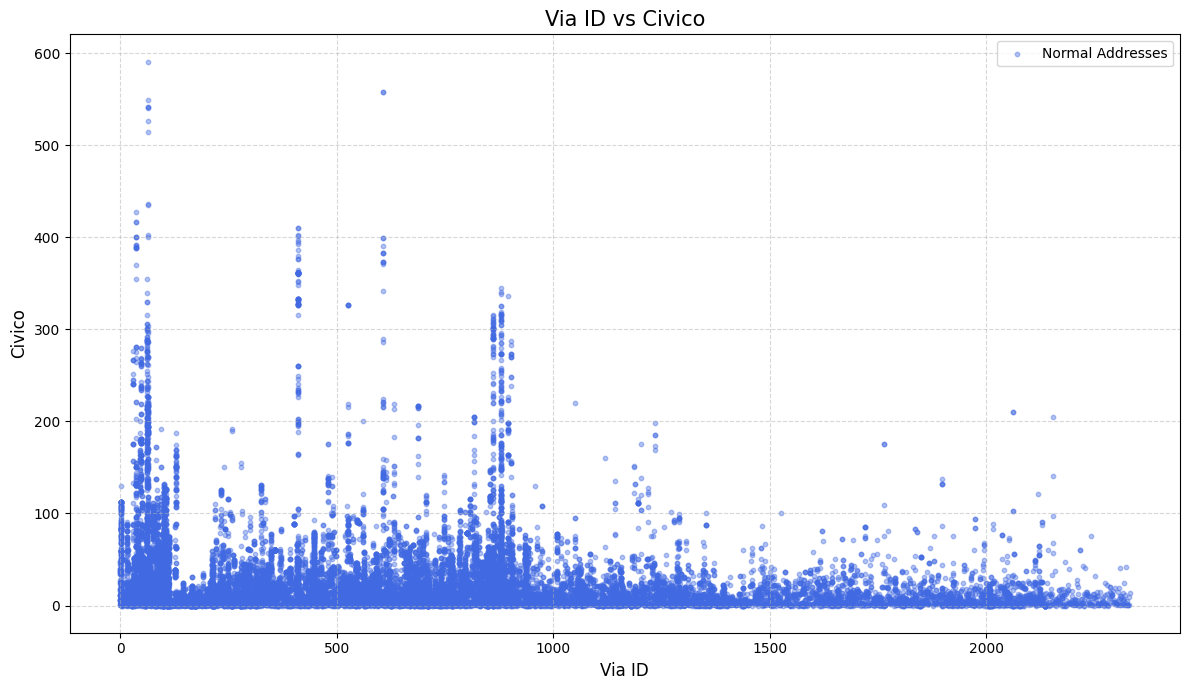

In [165]:
# Visualization of data after outliers detection
plt.figure(figsize=(12, 7))

plt.scatter(df['Via ID'], df['Civico'], 
            c='royalblue', s=10, alpha=0.4, label='Normal Addresses')

plt.title('Via ID vs Civico', fontsize=15)
plt.xlabel('Via ID', fontsize=12)
plt.ylabel('Civico', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

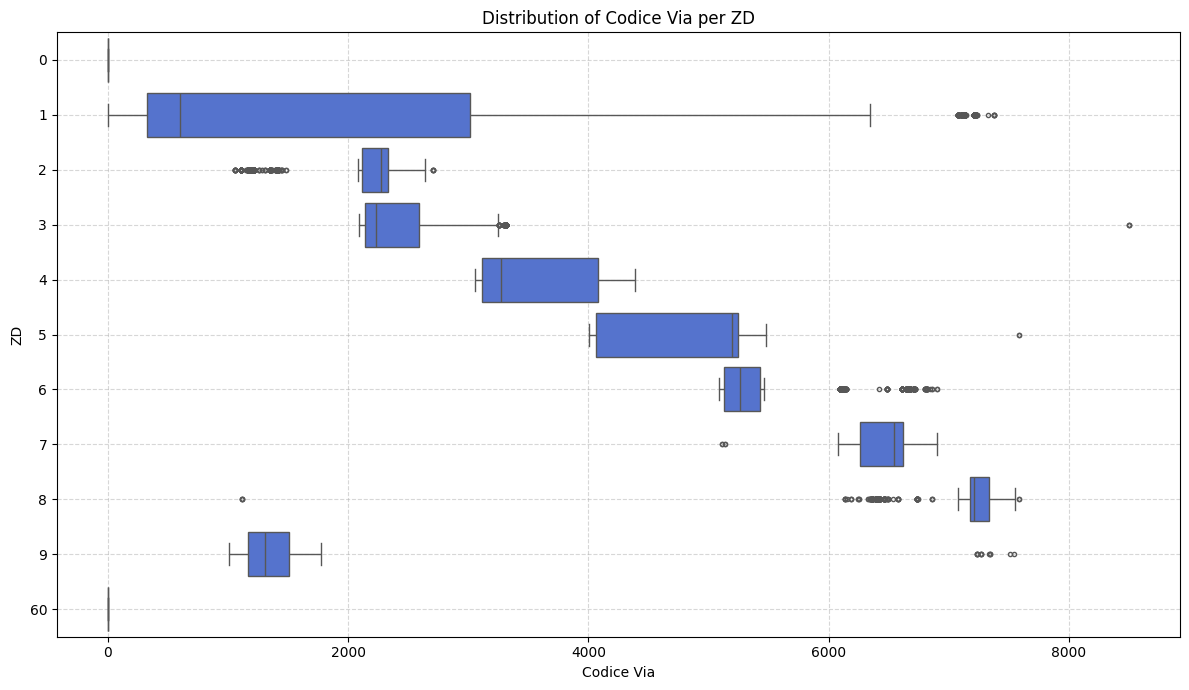

In [166]:
# Plot Codice Via with respect to the ZD they belong to

# Increase figure height if there are many streets to prevent squashing
plt.figure(figsize=(12, 7))

# Create the Box Plot (Whisker Plot)
# y = ZD (Continuous variable on X-axis)
# x = Codice Via (Categorical variable on Y-axis)
sns.boxplot(data=db, 
            x='Codice Via', 
            y='ZD', 
            color='royalblue',
            orient='h',
            fliersize=3)

plt.title('Distribution of Codice Via per ZD')
plt.ylabel('ZD')
plt.xlabel('Codice Via')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [167]:
# Detect outliers in ZD using Standard Deviation method
def STD(data, th):
    mean = data.mean()
    std = data.std()
    V1 = mean + th * std
    V2 = mean - th * std
    
    cleaned_data = []
    
    for d in data:
        if (d > V1) or (d < V2):
            cleaned_data.append(0)  # Found an outlier, replace with 0
        else:
            cleaned_data.append(d)  # Valid value, keep it
            
    return cleaned_data

# Detect outliers in 'ZD' column
db['ZD'] = STD(db['ZD'], th=3)

In [168]:
# Get unique values in 'ZD' column
db['ZD'].unique()

array([1, 4, 5, 8, 6, 3, 9, 7, 2, 0])

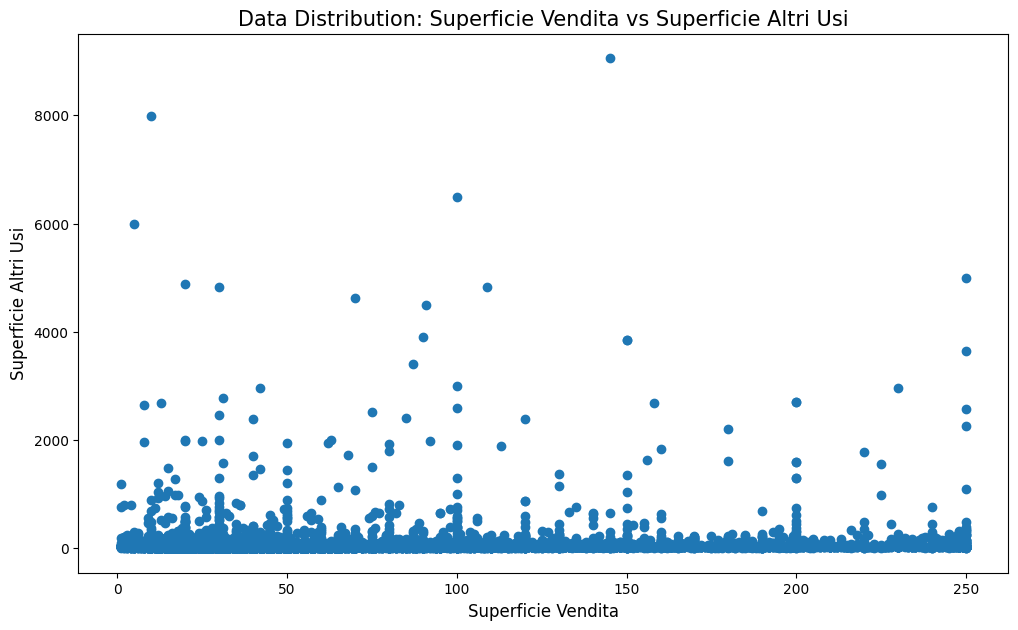

In [16]:
# Visualize data distribution to detect possible outliers
fig, ax = plt.subplots(figsize = (12,7))
ax.scatter(db['Superficie Vendita'], db['Superficie Altri Usi'])

plt.title('Data Distribution: Superficie Vendita vs Superficie Altri Usi', fontsize=15)
plt.xlabel('Superficie Vendita', fontsize=12)
plt.ylabel('Superficie Altri Usi', fontsize=12)
plt.show()

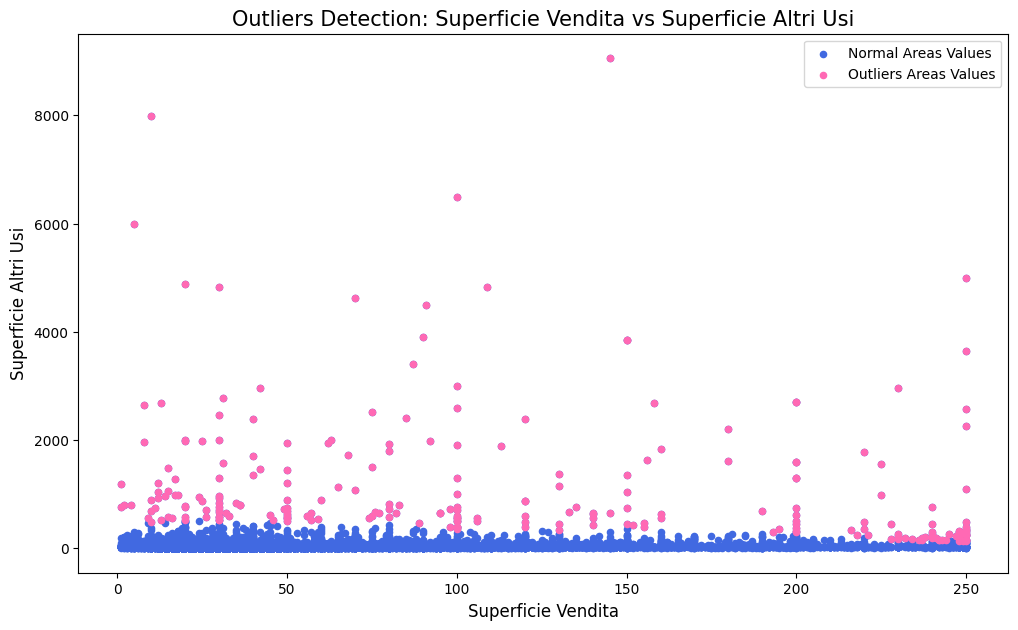

In [17]:
# Apply Isolation Forest algorithm to detect outliers based on the joint relationship between Superficie Vendita and Superficie Altri Usi
x_col = "Superficie Vendita"
y_col = "Superficie Altri Usi"
X = db[[x_col, y_col]].copy()

model = IsolationForest(n_estimators=100, max_samples='auto', contamination=0.01, max_features=1.0)
model.fit(X)
prova = pd.DataFrame()
prova['scores'] = model.decision_function(X)
prova['anomaly'] = model.predict(X)
anomaly = prova.loc[prova['anomaly'] == -1]
OUTLIER_INDEX = list(anomaly.index)

# Filter outlier values
OUTLIERS_VALUES = db.iloc[OUTLIER_INDEX]

fig, ax = plt.subplots(figsize = (12,7))

plt.title('Outliers Detection: Superficie Vendita vs Superficie Altri Usi', fontsize=15)
plt.xlabel('Superficie Vendita', fontsize=12)
plt.ylabel('Superficie Altri Usi', fontsize=12)
plt.scatter(db[x_col], db[y_col], color = "royalblue", s = 20, label='Normal Areas Values')
plt.scatter(OUTLIERS_VALUES[x_col], OUTLIERS_VALUES[y_col], color = "hotpink", s = 20, label='Outliers Areas Values')
plt.legend(loc='upper right')

plt.show()

In [18]:
# Replace outlier values with NaN to apply Random Forest for values imputation
db.loc[OUTLIER_INDEX, [x_col, y_col]] = np.nan

COLS = ['Alimentare', 'Non Alimentare', 'Tabella Speciale Carburanti',
       'Tabella Speciale Farmacie', 'Tabella Speciale Monopolio',
       'Tipo Via', 'Via', 'Civico', 'Codice Via', 'ZD', 'Isolato', 'Accesso', 
       'Settore Storico Cf Preval', 'Superficie Vendita', 'Superficie Altri Usi']

missing_columns = ["Superficie Vendita", "Superficie Altri Usi"]

IMP_DATA = pd.DataFrame(columns = ["IMP" + name for name in missing_columns])

CAT = list(db.select_dtypes(include=['boolean','object']).columns)
NUM = list(db.select_dtypes(include=['int64','float64']).columns)

for feature in missing_columns:

    db[feature + '_imp'] = db[feature]

    if feature in NUM:
      db.loc[db[feature].isnull(), feature + '_imp'] = db[feature].median()
    elif feature in CAT:
      db.loc[db[feature].isnull(), feature + '_imp'] = db[feature].mode()[0]

for feature in missing_columns:

    IMP_DATA["IMP" + feature] = db[feature]
    parameters = list(set(db.columns) - set(missing_columns) - {feature + '_imp'})

    if feature in NUM:
      model = ensemble.RandomForestRegressor()
    if feature in CAT:
      model = ensemble.RandomForestClassifier()

    X = s.encoding_categorical_variables(db[parameters])

    model.fit(X = X.loc[db[feature].notnull()], y = db[feature + '_imp'].loc[db[feature].notnull()])
    model_predicted = model.predict(X.loc[db[feature].isnull()])

    print("IMP" + feature + " successfully imputed")
    IMP_DATA.loc[db[feature].isnull(), "IMP" + feature] = model_predicted

IMPSuperficie Vendita successfully imputed
IMPSuperficie Altri Usi successfully imputed


In [19]:
# Drop original columns with missing data
db = db.drop(
    [
        "Superficie Vendita",
        "Superficie Altri Usi",
    ],
    axis=1
)

# Rename imputed columns
db = db.rename(columns={
    "Superficie Vendita_imp": "Superficie Vendita",
    "Superficie Altri Usi_imp": "Superficie Altri Usi"
})

# Reorder columns
db = db[['Alimentare', 'Non Alimentare', 'Tabella Speciale Carburanti',
       'Tabella Speciale Farmacie', 'Tabella Speciale Monopolio',
       'Tipo Via', 'Via', 'Civico', 'Codice Via', 'ZD', 'Isolato', 'Accesso', 
       'Settore Storico Cf Preval', 'Superficie Vendita', 'Superficie Altri Usi', 
       'Superficie Totale']]

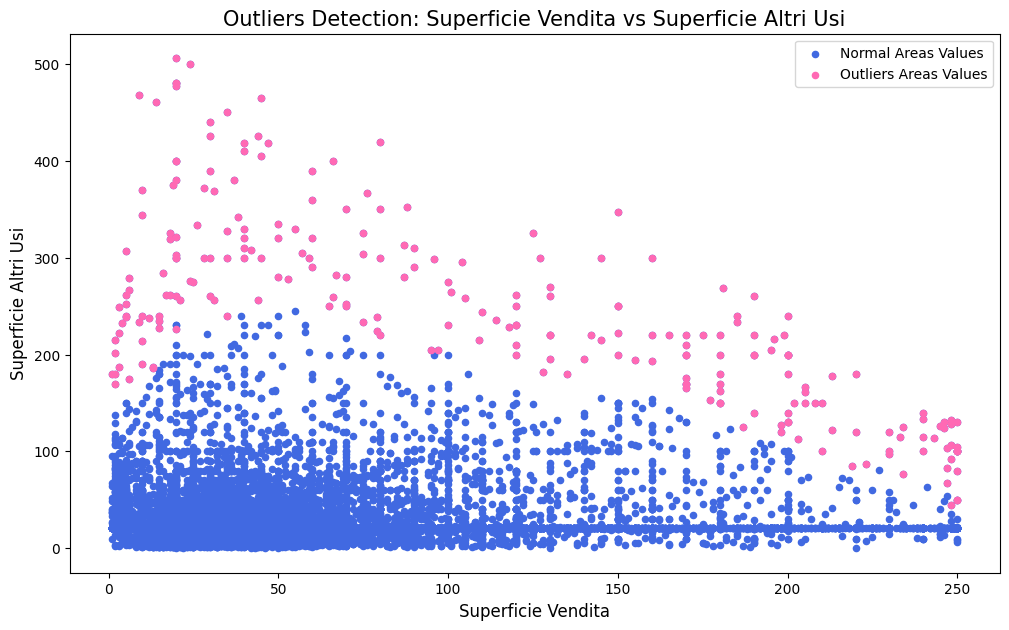

In [20]:
# Apply Isolation Forest algorithm to detect outliers based on the joint relationship between Superficie Vendita and Superficie Altri Usi
x_col = "Superficie Vendita"
y_col = "Superficie Altri Usi"
X = db[[x_col, y_col]].copy()

model = IsolationForest(n_estimators=100, max_samples='auto', contamination=0.01, max_features=1.0)
model.fit(X)
prova = pd.DataFrame()
prova['scores'] = model.decision_function(X)
prova['anomaly'] = model.predict(X)
anomaly = prova.loc[prova['anomaly'] == -1]
OUTLIER_INDEX = list(anomaly.index)

#Filter outlier values
OUTLIERS_VALUES = db.iloc[OUTLIER_INDEX]

#Plot data
fig, ax = plt.subplots(figsize = (12,7))

plt.title('Outliers Detection: Superficie Vendita vs Superficie Altri Usi', fontsize=15)
plt.xlabel('Superficie Vendita', fontsize=12)
plt.ylabel('Superficie Altri Usi', fontsize=12)
plt.scatter(db[x_col], db[y_col], color = "royalblue", s = 20, label='Normal Areas Values')
plt.scatter(OUTLIERS_VALUES[x_col], OUTLIERS_VALUES[y_col], color = "hotpink", s = 20, label='Outliers Areas Values')
plt.legend(loc='upper right')

plt.show()

In [21]:
# Save the database after handling outliers
db.to_csv("db_outliers_handled.csv", index=False)